# This notebook examines: The SC model converge to the same values for different $n_e$ boundary conditions?

We are going to look at 10 different equilibria from DIII-D using the same combination of free parameters each time

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve
from src.load_equil import initialize_inputs
from src.solver_nondim import saarelma_connor_nondim

from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk

In [20]:
verbose = True
verbose_sc = False

scale_ne_inners = np.logspace(-1, 1, 21) # includes 1

# Output data and files
out_dir = 'ten_equil'
Path(out_dir).mkdir(parents=True, exist_ok=True)

# Scan parameters
x_res = 20
eped_tol_max = 1e-5
free_params = {
    'alpha_crit': 0.1,
    'C_KBM': 1,
    'De_chie_etg': 0.1,
    'nFC_x0': 3.16228e15,
    'ncx_x0_ratio': 17.783
}

# Equilibria parameters
equil_num = 11
kprof_loc = 'pfile'
geqdsk_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks')
pfile_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles')
P_tot_e = 5e6
psi_N_inner = 0.85
# geqdsk_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode')
# pfile_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode')
ne_inner_bc = "neumann"
bc_origin = "p-file"
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_max_it = 50
picard_rtol = 1e-8
picard_relax = 1.0

In [21]:
# Load in equilibria
equilibria = initialize_inputs(equil_num, geqdsk_dir, pfile_dir, p_filetype=kprof_loc)

# don't use first equilibrium
equilibria = equilibria[1:]

Selected 11 g/pfile file pairs:
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g150840.03000
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p150840.03000
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g152960.03500
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p152960.03500
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153032.04475
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153032.04475
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153100.03000
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153100.03000
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153140.04750
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153140.04750
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153153.03800
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153153.03800
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/

In [22]:
# For each equilbrium, call profiles_loop_solve() from profiles_loop_solve.py
failed=[]
success=[]
sol_out = []
for mhd_fp, kprof_fp in equilibria:
    equil_tag = Path(mhd_fp).name[1:]
    print(equil_tag)

    # Load in free parameters
    if free_params is None:
        raise ValueError("Must specify free_params")
    alpha_crit = free_params['alpha_crit']
    C_KBM = free_params['C_KBM']
    De_chie_etg = free_params['De_chie_etg']
    nFC_x0 = free_params['nFC_x0']
    ncx_x0_ratio = free_params['ncx_x0_ratio']

    # Setup solver parameters
    SOLVE_KW = dict(
        x_res=x_res,
        fe_degree=2,
        ne_inner_bc=ne_inner_bc,   # Saarelma A7 default; see dirichlet comparison below
        bc_origin = bc_origin,
        linear_solver="lu",      # or "gamg" for GMRES + algebraic multigrid on J
        kbm_treatment=kbm_treatment,
        kbm_gate_eps=kbm_gate_eps, # 1e-3 minimum
        picard_gate_mode=picard_gate_mode,
        picard_max_it=picard_max_it,
        picard_rtol=picard_rtol,
        picard_relax=picard_relax,
        verbose=verbose_sc,
    )

    base_model = saarelma_connor_nondim(
            P_tot_e      = P_tot_e,
            alpha_crit   = alpha_crit,
            C_KBM        = C_KBM,
            De_chie_etg  = De_chie_etg,
            nFC_x0       = nFC_x0,
            ncx_x0_ratio = ncx_x0_ratio,
            psi_N_inner_boundary = psi_N_inner,
            mhd_fp       = mhd_fp,
            kprof_fp     = kprof_fp,
            kprof_loc    = kprof_loc,
            verbose      = verbose_sc,
            # psi_N_inner_boundary = 0.85, # set to None to use adaptive inner boundary method
    )
    for scale_ne_inner in scale_ne_inners:
        SOLVE_KW['scale_ne_inner'] = scale_ne_inner
        try:
            base_model.solve_coupled_nondim(**SOLVE_KW)
        except Exception as e:
            failed.append(mhd_fp)
        else:
            success.append(mhd_fp)
            sol = {
                'equil_tag': equil_tag,
                'x_sol': base_model.x_sol,
                'ne_sol': base_model.ne_sol,
                'psi_N': np.interp(base_model.x_sol, base_model.x_init, base_model.psi_N_pres),
                'nFC_sol': base_model.nFC_sol,
                'nCX_sol': base_model.nCX_sol,
                'scale_ne_inner': scale_ne_inner
            }
            sol_out.append(sol)
    
    out_path = Path(out_dir) / equil_tag
    out_path.mkdir(parents=True, exist_ok=True)
    np.save(out_path / 'success.npy', success)
    np.save(out_path / 'failed.npy', failed)
    np.save(out_path / 'sol_out.npy', sol_out)


152960.03500
153032.04475
153100.03000
153140.04750
153153.03800
153303.03100
153440.01725
153485.03500
153489.01800
153646.04200


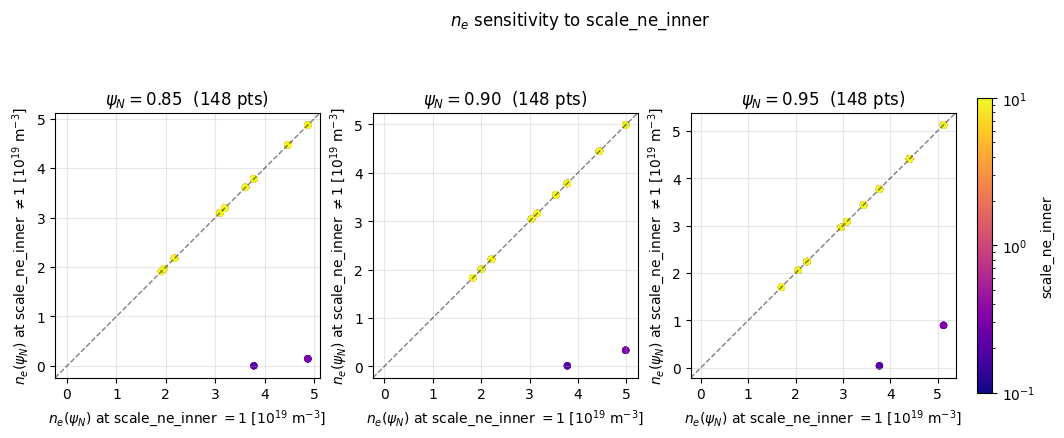

In [23]:
# Compare n_e(psiN) at scale_ne_inner != 1 vs scale_ne_inner = 1
from collections import defaultdict
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext

psiN_targets = [0.85, 0.90, 0.95]

by_equil = defaultdict(list)
for sol in sol_out:
    by_equil[sol['equil_tag']].append(sol)

scale_vals = np.asarray([s['scale_ne_inner'] for s in sol_out if not np.isclose(s['scale_ne_inner'], 1.0)])
norm = LogNorm(vmin=scale_vals.min(), vmax=scale_vals.max())

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
sc = None
for ax, psiN in zip(axes, psiN_targets):
    x_pts, y_pts, c_pts = [], [], []
    for sols in by_equil.values():
        ref = next((s for s in sols if np.isclose(s['scale_ne_inner'], 1.0)), None)
        if ref is None:
            continue
        ne_ref = float(np.interp(psiN, ref['psi_N'], ref['ne_sol'])) / 1e19
        for s in sols:
            if np.isclose(s['scale_ne_inner'], 1.0):
                continue
            ne_s = float(np.interp(psiN, s['psi_N'], s['ne_sol'])) / 1e19
            x_pts.append(ne_ref)
            y_pts.append(ne_s)
            c_pts.append(s['scale_ne_inner'])

    sc = ax.scatter(x_pts, y_pts, c=c_pts, cmap='plasma', norm=norm, s=28, edgecolors='none')
    lim_lo = min(min(x_pts), min(y_pts))
    lim_hi = max(max(x_pts), max(y_pts))
    pad = 0.05 * (lim_hi - lim_lo + 1e-30)
    ax.plot([lim_lo - pad, lim_hi + pad], [lim_lo - pad, lim_hi + pad], 'k--', lw=1, alpha=0.5)
    ax.set_xlim(lim_lo - pad, lim_hi + pad)
    ax.set_ylim(lim_lo - pad, lim_hi + pad)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(r'$n_e(\psi_N)$ at scale_ne_inner $= 1$ [$10^{19}$ m$^{-3}$]')
    ax.set_ylabel(r'$n_e(\psi_N)$ at scale_ne_inner $\neq 1$ [$10^{19}$ m$^{-3}$]')
    ax.set_title(rf'$\psi_N = {psiN:.2f}$  ({len(x_pts)} pts)')
    ax.grid(alpha=0.3)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
cbar.set_label(r'scale_ne_inner')
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
cbar.ax.minorticks_on()
fig.suptitle(r'$n_e$ sensitivity to scale_ne_inner', y=1.02)
plt.show()


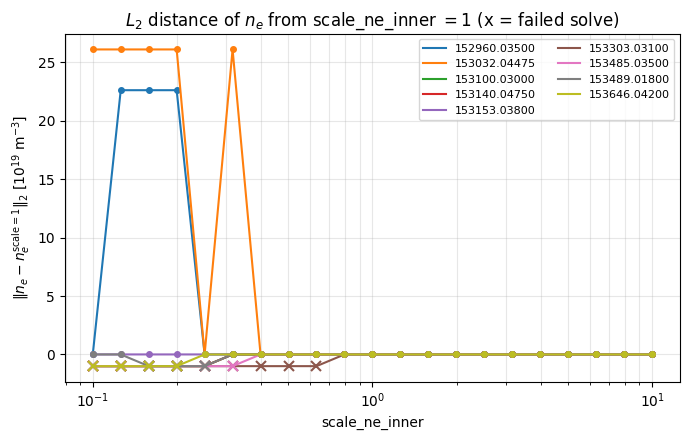

In [24]:
# L2 distance of n_e vs scale_ne_inner=1, one curve per equilibrium.
# Missing (failed) scales are marked with 'x' at y=-1 so each curve spans all scale_ne_inners.
from collections import defaultdict

by_equil = defaultdict(list)
for sol in sol_out:
    by_equil[sol['equil_tag']].append(sol)

fig, ax = plt.subplots(figsize=(7, 4.5))
for equil_tag, sols in by_equil.items():
    ref = next((s for s in sols if np.isclose(s['scale_ne_inner'], 1.0)), None)
    if ref is None:
        # No reference solve: mark every scale as failed
        scales = list(scale_ne_inners)
        l2s = [-1.0] * len(scales)
        ok = np.zeros(len(scales), dtype=bool)
    else:
        psi_ref = np.asarray(ref['psi_N'], dtype=float)
        ne_ref = np.asarray(ref['ne_sol'], dtype=float)
        scales, l2s, ok = [], [], []
        for scale in scale_ne_inners:
            s = next((d for d in sols if np.isclose(d['scale_ne_inner'], scale)), None)
            if s is None:
                scales.append(scale)
                l2s.append(-1.0)
                ok.append(False)
            else:
                ne_i = np.interp(psi_ref, s['psi_N'], s['ne_sol'])
                l2 = float(np.linalg.norm(ne_i - ne_ref) / 1e19)
                scales.append(scale)
                l2s.append(l2)
                ok.append(True)
        ok = np.asarray(ok, dtype=bool)

    scales = np.asarray(scales, dtype=float)
    l2s = np.asarray(l2s, dtype=float)
    line, = ax.plot(scales, l2s, '-', lw=1.5, label=equil_tag)
    color = line.get_color()
    if ok.any():
        ax.plot(scales[ok], l2s[ok], 'o', ms=4, color=color)
    if (~ok).any():
        ax.plot(scales[~ok], l2s[~ok], 'x', ms=7, mew=1.5, color=color)

ax.set_xscale('log')
ax.set_xlabel(r'scale_ne_inner')
ax.set_ylabel(r'$\|n_e - n_e^{\mathrm{scale}=1}\|_2$ [$10^{19}$ m$^{-3}$]')
ax.set_title(r'$L_2$ distance of $n_e$ from scale_ne_inner $= 1$ (x = failed solve)')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=8, loc='best', ncol=2)
fig.tight_layout()
plt.show()
